# Task 4: Optimize Portfolio Based on Forecast

**Objective:** Use insights from your forecast to construct an optimal portfolio using Modern Portfolio Theory (MPT).

This notebook covers:
- Preparing expected returns from forecasts and historical data
- Computing covariance matrix
- Generating the efficient frontier
- Identifying optimal portfolios
- Recommending a final portfolio

## Import Required Libraries

In [20]:
# Import required libraries
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import yfinance as yf
from datetime import datetime

# Import project modules
import sys
sys.path.append('..')
from src.config.settings import Settings

settings = Settings()

# Import plotter utility
from src.utils.plotter import Plotter
plotter = Plotter()

## Prepare Expected Returns

In [21]:
# Load historical data
tickers = ['TSLA', 'BND', 'SPY']
start_date = '2015-01-01'
end_date = '2026-01-15'

data = {}
for ticker in tickers:
    data[ticker] = yf.download(ticker, start=start_date, end=end_date)
    print(f"{ticker} columns: {data[ticker].columns}")

# Calculate daily returns
returns = {}
for ticker in tickers:
    # Handle MultiIndex columns from yfinance - use 'Close' instead of 'Adj Close'
    if isinstance(data[ticker].columns, pd.MultiIndex):
        close_price = data[ticker][('Close', ticker)]
    else:
        close_price = data[ticker]['Close']
    returns[ticker] = close_price.pct_change().dropna()

# Expected returns: Forecasted for TSLA, historical for others
# For TSLA, use a simple ARIMA forecast
from statsmodels.tsa.arima.model import ARIMA

# Handle MultiIndex for TSLA - use 'Close'
if isinstance(data['TSLA'].columns, pd.MultiIndex):
    tsla_prices = data['TSLA'][('Close', 'TSLA')]
else:
    tsla_prices = data['TSLA']['Close']

model = ARIMA(tsla_prices, order=(5, 1, 0))
fitted_model = model.fit()
forecast_steps = 252  # 1 year
forecast = fitted_model.forecast(steps=forecast_steps)
tsla_forecast_return = (forecast.iloc[-1] - tsla_prices.iloc[-1]) / tsla_prices.iloc[-1]

expected_returns = pd.Series({
    'TSLA': tsla_forecast_return,
    'BND': returns['BND'].mean() * 252,  # Annualized
    'SPY': returns['SPY'].mean() * 252
})

print("Expected Annual Returns:")
print(expected_returns)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

TSLA columns: MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
BND columns: MultiIndex([( 'Close', 'BND'),
            (  'High', 'BND'),
            (   'Low', 'BND'),
            (  'Open', 'BND'),
            ('Volume', 'BND')],
           names=['Price', 'Ticker'])



c:\BackUp\web-projects\tenx\financial-portfolio-forecasting-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\BackUp\web-projects\tenx\financial-portfolio-forecasting-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\BackUp\web-projects\tenx\financial-portfolio-forecasting-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SPY columns: MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])
Expected Annual Returns:
TSLA    0.000429
BND     0.020434
SPY     0.142850
dtype: float64


c:\BackUp\web-projects\tenx\financial-portfolio-forecasting-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\BackUp\web-projects\tenx\financial-portfolio-forecasting-week9\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Compute Covariance Matrix

Covariance Matrix:
          TSLA       BND       SPY
TSLA  0.332840  0.001667  0.050172
BND   0.001667  0.002869  0.001013
SPY   0.050172  0.001013  0.031569


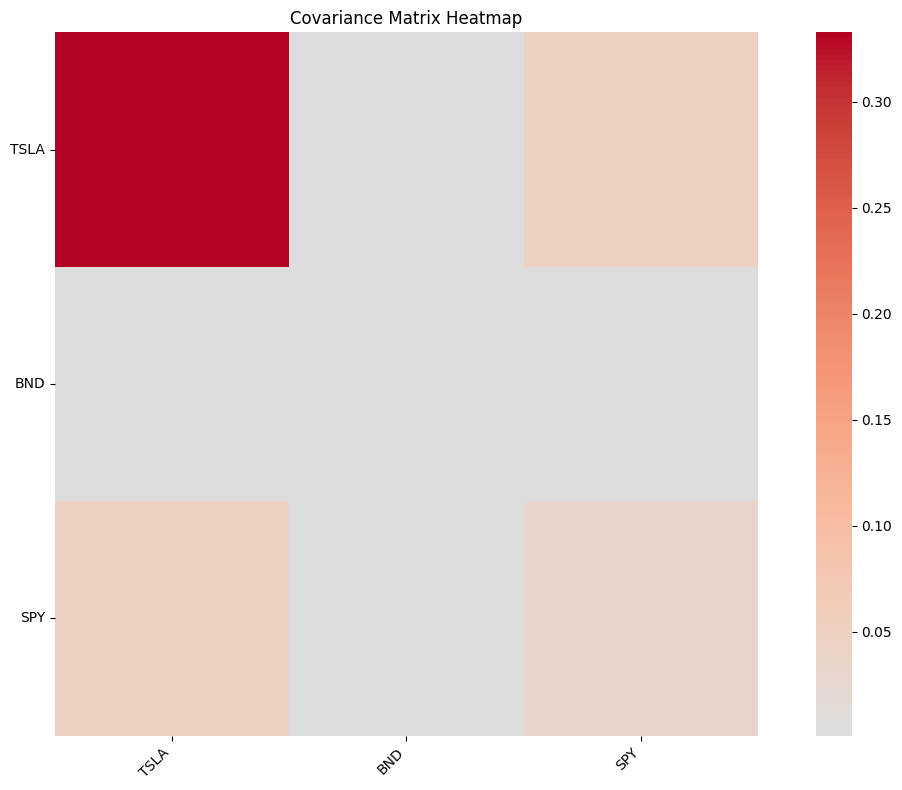

In [22]:
# Covariance matrix (annualized)
returns_df = pd.DataFrame(returns)
cov_matrix = returns_df.cov() * 252
print("Covariance Matrix:")
print(cov_matrix)

# Visualize covariance matrix
plotter.plot_heatmap(cov_matrix, title='Covariance Matrix Heatmap')

## Generate the Efficient Frontier

In [23]:
# Portfolio optimization functions
def portfolio_performance(weights, expected_returns, cov_matrix):
    port_return = np.dot(weights, expected_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = port_return / port_vol  # Assuming rf=0
    return port_return, port_vol, sharpe

def minimize_volatility(weights):
    return portfolio_performance(weights, expected_returns, cov_matrix)[1]

def maximize_sharpe(weights):
    return -portfolio_performance(weights, expected_returns, cov_matrix)[2]

# Constraints and bounds
constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
bounds = [(0, 1) for _ in range(len(expected_returns))]

# Generate Efficient Frontier
target_returns = np.linspace(expected_returns.min(), expected_returns.max(), 50)
efficient_frontier = []

for target in target_returns:
    def target_constraint(weights):
        return np.dot(weights, expected_returns) - target
    constraints_with_target = constraints + [{'type': 'eq', 'fun': target_constraint}]
    result = minimize(minimize_volatility, [1/3]*3, method='SLSQP', bounds=bounds, constraints=constraints_with_target)
    if result.success:
        ret, vol, _ = portfolio_performance(result.x, expected_returns, cov_matrix)
        efficient_frontier.append((vol, ret))

efficient_frontier = np.array(efficient_frontier)

## Visualize and Identify Key Portfolios

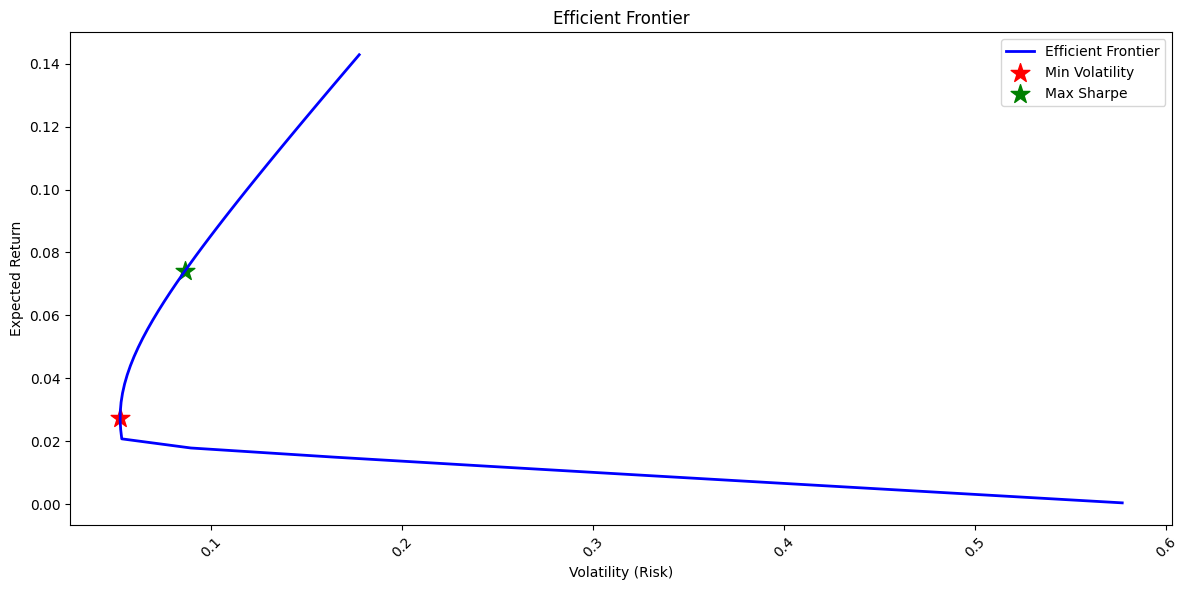

Minimum Volatility Portfolio:
Weights: {'TSLA': np.float64(8.673617379884035e-18), 'BND': np.float64(0.942864793136539), 'SPY': np.float64(0.057135206863460936)}
Return: 0.0274, Volatility: 0.0526, Sharpe: 0.5218

Maximum Sharpe Ratio Portfolio:
Weights: {'TSLA': np.float64(0.0), 'BND': np.float64(0.5618220047866833), 'SPY': np.float64(0.4381779952135283)}
Return: 0.0741, Volatility: 0.0864, Sharpe: 0.8573


In [24]:
# Find key portfolios
min_vol_result = minimize(minimize_volatility, [1/3]*3, method='SLSQP', bounds=bounds, constraints=constraints)
min_vol_weights = min_vol_result.x
min_vol_return, min_vol_vol, min_vol_sharpe = portfolio_performance(min_vol_weights, expected_returns, cov_matrix)

max_sharpe_result = minimize(maximize_sharpe, [1/3]*3, method='SLSQP', bounds=bounds, constraints=constraints)
max_sharpe_weights = max_sharpe_result.x
max_sharpe_return, max_sharpe_vol, max_sharpe_sharpe = portfolio_performance(max_sharpe_weights, expected_returns, cov_matrix)

# Plot Efficient Frontier
data_dict = {
    'Efficient Frontier': (efficient_frontier[:, 0], efficient_frontier[:, 1], {'linestyle': '-', 'color': 'blue', 'linewidth': 2}),
    'Min Volatility': ([min_vol_vol], [min_vol_return], {'marker': '*', 'color': 'red', 's': 200}),
    'Max Sharpe': ([max_sharpe_vol], [max_sharpe_return], {'marker': '*', 'color': 'green', 's': 200})
}
plotter.plot_scatter_with_overlays(data_dict, title='Efficient Frontier', xlabel='Volatility (Risk)', ylabel='Expected Return')

print("Minimum Volatility Portfolio:")
print(f"Weights: {dict(zip(expected_returns.index, min_vol_weights))}")
print(f"Return: {min_vol_return:.4f}, Volatility: {min_vol_vol:.4f}, Sharpe: {min_vol_sharpe:.4f}")

print("\nMaximum Sharpe Ratio Portfolio:")
print(f"Weights: {dict(zip(expected_returns.index, max_sharpe_weights))}")
print(f"Return: {max_sharpe_return:.4f}, Volatility: {max_sharpe_vol:.4f}, Sharpe: {max_sharpe_sharpe:.4f}")

## Recommend Optimal Portfolio

In [25]:
# Portfolio Recommendation
print("="*60)
print("PORTFOLIO OPTIMIZATION RESULTS")
print("="*60)

print("Recommended Portfolio: Maximum Sharpe Ratio Portfolio")
print("This portfolio offers the best risk-adjusted returns, balancing growth potential from TSLA with stability from BND and SPY.")
print(f"\nWeights:")
print(f"  TSLA: {max_sharpe_weights[0]:.2%}")
print(f"  BND: {max_sharpe_weights[1]:.2%}")
print(f"  SPY: {max_sharpe_weights[2]:.2%}")
print(f"\nExpected Annual Return: {max_sharpe_return:.2%}")
print(f"Expected Annual Volatility: {max_sharpe_vol:.2%}")
print(f"Sharpe Ratio: {max_sharpe_sharpe:.2f}")

print("\nAlternative: Minimum Volatility Portfolio")
print(f"Weights: TSLA: {min_vol_weights[0]:.2%}, BND: {min_vol_weights[1]:.2%}, SPY: {min_vol_weights[2]:.2%}")
print(f"Return: {min_vol_return:.2%}, Volatility: {min_vol_vol:.2%}, Sharpe: {min_vol_sharpe:.2f}")

print("\nJUSTIFICATION:")
print("The Maximum Sharpe Ratio portfolio is recommended because it provides the highest return per unit of risk.")
print("Given the forecasted growth in TSLA, this portfolio captures upside potential while maintaining diversification.")
print("For risk-averse investors, the Minimum Volatility portfolio could be considered as an alternative.")

print(f"\n" + "="*60)
print("END OF TASK 4 - PORTFOLIO OPTIMIZATION")
print("="*60)

PORTFOLIO OPTIMIZATION RESULTS
Recommended Portfolio: Maximum Sharpe Ratio Portfolio
This portfolio offers the best risk-adjusted returns, balancing growth potential from TSLA with stability from BND and SPY.

Weights:
  TSLA: 0.00%
  BND: 56.18%
  SPY: 43.82%

Expected Annual Return: 7.41%
Expected Annual Volatility: 8.64%
Sharpe Ratio: 0.86

Alternative: Minimum Volatility Portfolio
Weights: TSLA: 0.00%, BND: 94.29%, SPY: 5.71%
Return: 2.74%, Volatility: 5.26%, Sharpe: 0.52

JUSTIFICATION:
The Maximum Sharpe Ratio portfolio is recommended because it provides the highest return per unit of risk.
Given the forecasted growth in TSLA, this portfolio captures upside potential while maintaining diversification.
For risk-averse investors, the Minimum Volatility portfolio could be considered as an alternative.

END OF TASK 4 - PORTFOLIO OPTIMIZATION


### Summary

This notebook demonstrates the application of Modern Portfolio Theory (MPT) to optimize a portfolio consisting of TSLA, BND, and SPY. The workflow includes:

- **Data Preparation:** Historical price data is downloaded for each asset. Daily returns are calculated, and expected returns are estimated using a combination of ARIMA forecasting (for TSLA) and historical averages (for BND and SPY).
- **Covariance Matrix:** The annualized covariance matrix of asset returns is computed and visualized to understand inter-asset risk relationships.
- **Efficient Frontier:** Using numerical optimization, the efficient frontier is generated, showing the best possible expected return for each level of risk.
- **Key Portfolios:** The minimum volatility and maximum Sharpe ratio portfolios are identified and their weights, returns, volatilities, and Sharpe ratios are reported.
- **Recommendation:** The maximum Sharpe ratio portfolio is recommended for its optimal risk-adjusted return, with the minimum volatility portfolio as an alternative for risk-averse investors.

### Figure Index

1. **Covariance Matrix Heatmap**  
    *Location: Covariance Matrix section*  
    *Description:* Visualizes the annualized covariance matrix of TSLA, BND, and SPY returns.

2. **Efficient Frontier Plot**  
    *Location: Visualize and Identify Key Portfolios section*  
    *Description:* Shows the efficient frontier, highlighting the minimum volatility and maximum Sharpe ratio portfolios.